Training S&P 500 Baseline LSTM...

S&P 500 LSTM PAPER REPLICATION METRICS
R²:   0.9783
RMSE: 0.000712
MAPE: 0.0382


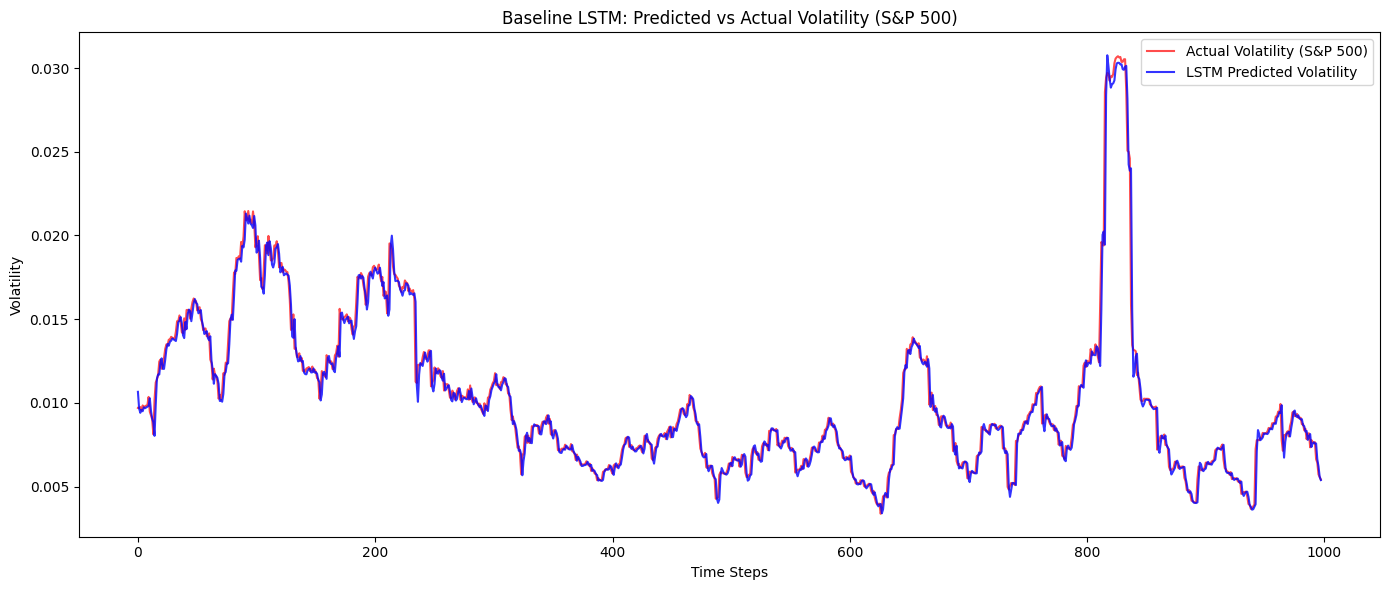

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings

warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# =============================================================================
# 1. LOAD DATASET
# =============================================================================
train_df = pd.read_csv("../Data/sp500_train (2) (1).csv")
test_df  = pd.read_csv("../Data/sp500_test (2) (1).csv")

train_df["Date"] = pd.to_datetime(train_df["Date"])
test_df["Date"]  = pd.to_datetime(test_df["Date"])

train_df = train_df.sort_values("Date").set_index("Date")
test_df  = test_df.sort_values("Date").set_index("Date")

# =============================================================================
# 2. WALK-FORWARD DATASET CONSTRUCTION (Paper Section III-C)
# =============================================================================
LOOKBACK  = 4   
PRED_STEP = 1   

def build_sequences(series, lookback=4):
    X, y = [], []
    for i in range(lookback, len(series) - PRED_STEP + 1):
        X.append(series[i - lookback : i])   
        y.append(series[i])                  
    return np.array(X), np.array(y)

X_train_raw, y_train_raw = build_sequences(train_df["Volatility"].values, lookback=LOOKBACK)
X_test_raw,  y_test_raw  = build_sequences(test_df["Volatility"].values,  lookback=LOOKBACK)

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train_raw)
X_test_scaled  = scaler_X.transform(X_test_raw)

y_train_scaled = scaler_y.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
y_test_scaled  = scaler_y.transform(y_test_raw.reshape(-1, 1)).ravel()

X_train = X_train_scaled.reshape(-1, LOOKBACK, 1)
X_test  = X_test_scaled.reshape(-1, LOOKBACK, 1)

# =============================================================================
# 3. MODEL ARCHITECTURE & TRAINING
# =============================================================================
model = Sequential([
    LSTM(64, input_shape=(LOOKBACK, 1), return_sequences=False),
    Dropout(0.2),
    Dense(1)
], name="LSTM_Vol_Forecaster")

model.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=0
)

print("Training S&P 500 Baseline LSTM...")
history = model.fit(
    X_train, y_train_scaled,
    epochs=200,
    batch_size=32,
    validation_split=0.10,
    callbacks=[early_stop],
    verbose=0
)

# =============================================================================
# 4. PAPER REPLICATION EVALUATION METRICS
# =============================================================================
preds_scaled = model.predict(X_test, verbose=0)
preds = scaler_y.inverse_transform(preds_scaled).flatten()
actuals = y_test_raw

r2 = r2_score(actuals, preds)
mse = mean_squared_error(actuals, preds)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(actuals, preds)

print(f"\n{'='*50}")
print("S&P 500 LSTM PAPER REPLICATION METRICS")
print(f"{'='*50}")
print(f"R²:   {r2:.4f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAPE: {mape:.4f}")

# Plotting the comparison
plt.figure(figsize=(14, 6))
plt.plot(actuals, label='Actual Volatility (S&P 500)', color='red', alpha=0.7)
plt.plot(preds, label='LSTM Predicted Volatility', color='blue', alpha=0.8)
plt.title('Baseline LSTM: Predicted vs Actual Volatility (S&P 500)')
plt.xlabel('Time Steps')
plt.ylabel('Volatility')
plt.legend()
plt.tight_layout()
plt.show()